In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML models
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [2]:
# Load training data
X_train = pd.read_csv("UCI HAR Dataset/train/X_train.txt", delim_whitespace=True, header=None)
y_train = pd.read_csv("UCI HAR Dataset/train/y_train.txt", header=None)

# Load testing data
X_test = pd.read_csv("UCI HAR Dataset/test/X_test.txt", delim_whitespace=True, header=None)
y_test = pd.read_csv("UCI HAR Dataset/test/y_test.txt", header=None)

# Quick check
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


/tmp/ipykernel_197/690749513.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_train = pd.read_csv("UCI HAR Dataset/train/X_train.txt", delim_whitespace=True, header=None)
/tmp/ipykernel_197/690749513.py:6: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_test = pd.read_csv("UCI HAR Dataset/test/X_test.txt", delim_whitespace=True, header=None)


X_train shape: (7352, 561)
y_train shape: (7352, 1)
X_test shape: (2947, 561)
y_test shape: (2947, 1)


In [3]:
# Load activity labels
activity_labels = pd.read_csv("UCI HAR Dataset/activity_labels.txt", delim_whitespace=True, header=None, names=["id", "activity"])
activity_map = dict(zip(activity_labels["id"], activity_labels["activity"]))

# Map numeric labels to activity names
y_train[0] = y_train[0].map(activity_map)
y_test[0] = y_test[0].map(activity_map)

# Check mapping
print(y_train[0].value_counts())


0
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64


/tmp/ipykernel_197/648037776.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  activity_labels = pd.read_csv("UCI HAR Dataset/activity_labels.txt", delim_whitespace=True, header=None, names=["id", "activity"])


In [4]:
# Display first 5 rows of X_train and y_train
X_train.head()
y_train.head()


,0
0,STANDING
1,STANDING
2,STANDING
3,STANDING
4,STANDING


In [5]:
# Initialize Random Forest model
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf.fit(X_train, y_train.values.ravel())

# Predict on test data
y_pred_rf = rf.predict(X_test)

# Accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", rf_accuracy)

# Classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.9267051238547676

Classification Report:
                     precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.91      0.90      0.90       491
          STANDING       0.91      0.92      0.91       532
           WALKING       0.89      0.97      0.93       496
WALKING_DOWNSTAIRS       0.97      0.87      0.92       420
  WALKING_UPSTAIRS       0.89      0.89      0.89       471

          accuracy                           0.93      2947
         macro avg       0.93      0.92      0.93      2947
      weighted avg       0.93      0.93      0.93      2947



In [6]:
# Initialize SVM model
svm = SVC()

# Train SVM
svm.fit(X_train, y_train.values.ravel())

# Predict on test data
y_pred_svm = svm.predict(X_test)

# Accuracy
svm_accuracy = accuracy_score(y_test, y_pred_svm)
print("SVM Accuracy:", svm_accuracy)

# Optional classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))


SVM Accuracy: 0.9504580929759077

Classification Report:
                     precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.94      0.89      0.91       491
          STANDING       0.91      0.95      0.93       532
           WALKING       0.94      0.98      0.96       496
WALKING_DOWNSTAIRS       0.99      0.91      0.95       420
  WALKING_UPSTAIRS       0.93      0.96      0.94       471

          accuracy                           0.95      2947
         macro avg       0.95      0.95      0.95      2947
      weighted avg       0.95      0.95      0.95      2947



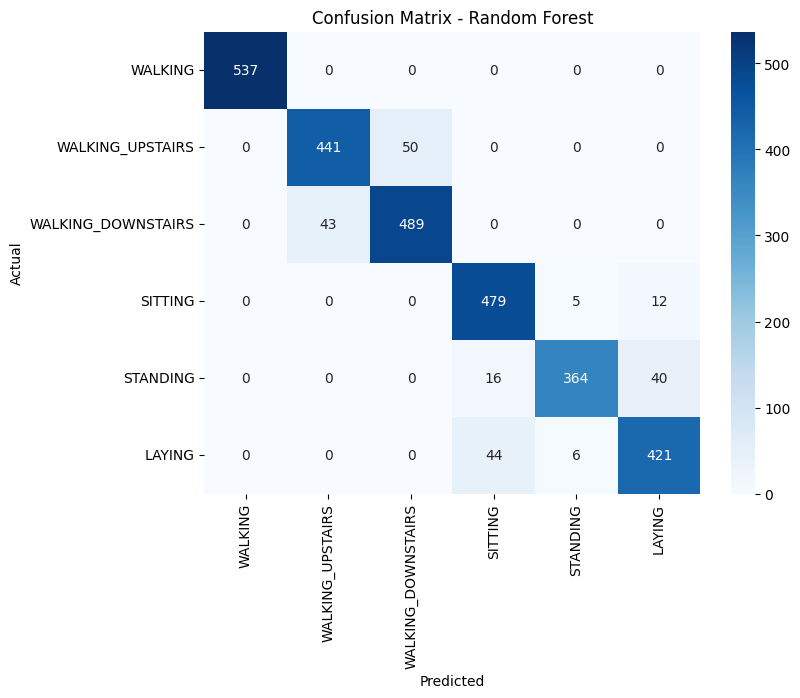

In [7]:
# Random Forest Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=activity_labels["activity"],
            yticklabels=activity_labels["activity"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()


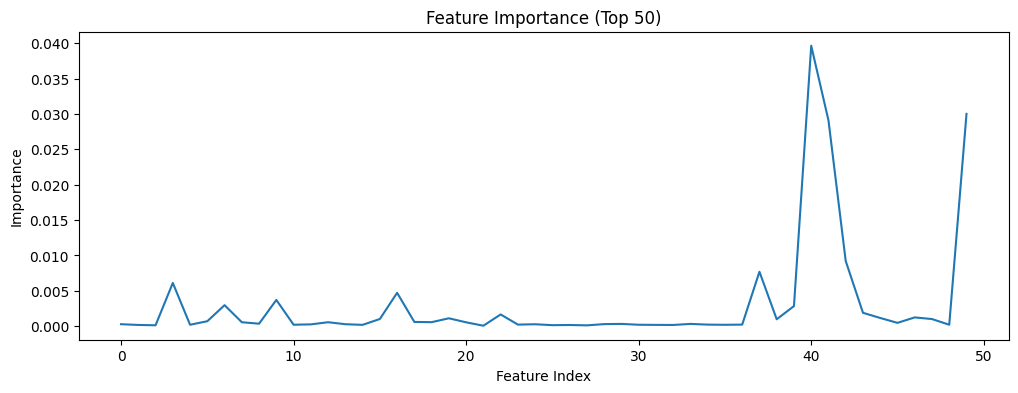

In [8]:
importances = rf.feature_importances_

plt.figure(figsize=(12,4))
plt.plot(importances[:50])  # show first 50 features
plt.title("Feature Importance (Top 50)")
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.show()


In [10]:
# Static activities
static_activities = ["SITTING", "STANDING", "LAYING"]

# Dynamic activities
dynamic_activities = ["WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS"]



In [11]:
# Boolean masks for test set
static_idx = y_test[0].isin(static_activities)
dynamic_idx = y_test[0].isin(dynamic_activities)


In [12]:
# Random Forest
static_acc = accuracy_score(y_test[0][static_idx], y_pred_rf[static_idx])
dynamic_acc = accuracy_score(y_test[0][dynamic_idx], y_pred_rf[dynamic_idx])

print("Random Forest Accuracy on Static Activities:", round(static_acc, 4))
print("Random Forest Accuracy on Dynamic Activities:", round(dynamic_acc, 4))


Random Forest Accuracy on Static Activities: 0.9404
Random Forest Accuracy on Dynamic Activities: 0.9113


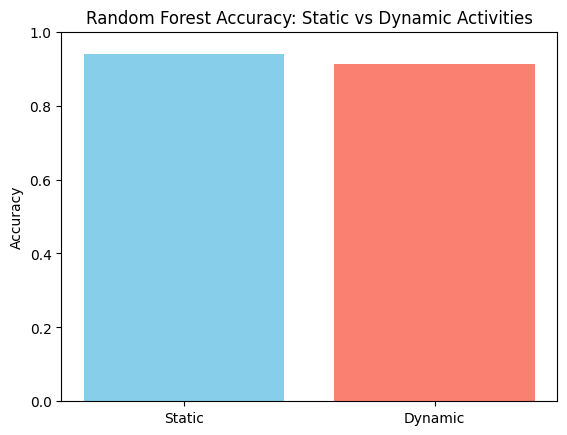

In [13]:
plt.bar(["Static", "Dynamic"], [static_acc, dynamic_acc], color=["skyblue", "salmon"])
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Random Forest Accuracy: Static vs Dynamic Activities")
plt.show()


In [14]:
# Save summary results to CSV
results_summary = pd.DataFrame({
    "Model": ["Random Forest", "SVM"],
    "Overall Accuracy": [rf_accuracy, svm_accuracy],
    "Static Accuracy (RF)": [static_acc, None],
    "Dynamic Accuracy (RF)": [dynamic_acc, None]
})

results_summary.to_csv("har_results_summary.csv", index=False)
